In [83]:
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [113]:
X,y = make_regression(n_samples=1000,n_features=2,random_state=42)
X = pd.DataFrame(X,columns=['X1','X2'])
y = pd.Series(y,name='Y')
df = pd.concat([X,y],axis=1)
df

,X1,X2,Y
0,0.430042,0.381935,18.387538
1,1.561511,1.301741,63.302244
2,-0.566298,-0.990536,-44.063499
3,0.047399,-0.651836,-26.223793
4,1.676437,0.018418,11.815961
...,...,...,...
995,-0.767348,2.153182,82.592206
996,-0.987180,-0.211130,-15.111606
997,1.772252,-0.027515,10.578456
998,0.563909,1.384273,60.077000


In [116]:
corr = df['X1'].corr(y)
corr

np.float64(0.17116176702187222)

In [86]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=20)

In [32]:
X_train

,0,1
826,1.876796,0.413435
964,-0.393339,0.368673
439,0.361504,-0.612437
614,-0.309116,0.192049
696,1.080781,0.559790
...,...,...
924,0.375698,-1.150994
223,-1.143005,0.638730
271,-1.739714,1.148766
474,-0.753736,-0.245388


In [33]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression()

In [45]:
linear.fit(pd.DataFrame(X_train[1]),y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[40.72]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.31]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[25.86]


In [46]:
linear.coef_

array([[40.71912125]])

In [47]:
linear.intercept_

array([0.310941])

In [49]:
y_pred = linear.predict(pd.DataFrame(X_test[0]))

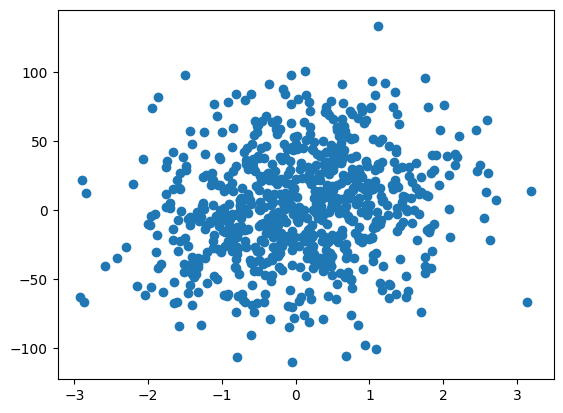

In [50]:
plt.scatter(X_train.iloc[:,0],y_train)
plt.show()

In [51]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score


-0.6556131516826322

In [52]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse = mean_squared_error(y_test,y_pred)
mse

2865.6457725199275

In [101]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((750, 1), (250, 1), (750, 1), (250, 1))

In [102]:
X_train = pd.DataFrame(X_train[0])
X_test = pd.DataFrame(X_test[0])
X_train.shape,X_test.shape

((750, 1), (250, 1))

In [103]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [104]:
linear = LinearRegression()
linear.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 6)","[[ 0. , 6.2 ,-0.75, 0.7 ,-0.08,-0.1 ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.28]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[752.25,252.7 , 44.75, 17.16, 10.1 , 0. ]"


In [105]:
y_pred = linear.predict(X_test_poly)
y_pred.shape

(250, 1)

In [106]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.0004792876094650289

In [ ]:
corr = X